In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 35 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (10.2 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 121749 files and direc

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import matplotlib

# 맑은 고딕 적용
matplotlib.rc("font", family = "Nanum Gothic")
# 음수 표시
matplotlib.rc('axes', unicode_minus=False)

In [ ]:
# 실행결과 경고메시지 출력 제외
import warnings

warnings.filterwarnings('ignore')

In [ ]:
import pandas as pd
import numpy as np

# 데이터 시각화
import matplotlib.pyplot as plt
import matplotlib

import seaborn as sns

In [ ]:
plt.rc('font', family='NanumBarunGothic')

## 데이터 설명   

목표변수
- Price 중고차 가격 (단위 : 1,000원)  

설명변수

- Name : 자동차 브랜드와 모델의 이름
- Location : 자동차를 팔거나 구매할 수 있는 위치
- Year : 모델의 년도 혹은 버전
- Kilometers_Driven : 이전 소유주의 차량 주행거리(Km)
- Fuel_Type : 자동차의 사용연료의 종류
- Transmission : 자동차의 사용 변속기 종류(Manual/Automatic)
- Owner_Type : 소유권이 직접 소유인지, 중고 소유인지 여부
- Mileage : 자동차 회사가 제공하는 표준주행거리(kmpl)
- Engine : 엔진의 배기량(cc)
- Power : 엔진의 최대 출력(bhp)
- Seats : 차의 좌석 수
- New_Price : 뉴 모델의 가격

## 데이터 전처리

In [ ]:
df_raw = pd.read_csv('/content/drive/MyDrive/최강<포빅아A4>/인도 중고차 /Car.csv')
df_raw.head()

,Name,Location,Price,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price
0,Maruti Wagon R LXI CNG,Mumbai,2682.68,2010,72000,CNG,Manual,First,26.6 kmpl,998 CC,58.16 bhp,5.0,NaN
1,Hyundai Creta 1.6 CRDi SX Option,Pune,19162.00,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN
2,Honda Jazz V,Chennai,6898.32,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh
3,Maruti Ertiga VDI,Chennai,9197.76,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN
4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,27194.71,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN


<Power 문제>

In [ ]:
df_raw.shape

(7253, 13)

In [ ]:
df_raw.info() #데이터 열 정보 확인

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7253 entries, 0 to 7252
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               7253 non-null   object 
 1   Location           7253 non-null   object 
 2   Price              6200 non-null   float64
 3   Year               7253 non-null   int64  
 4   Kilometers_Driven  7253 non-null   int64  
 5   Fuel_Type          7253 non-null   object 
 6   Transmission       7253 non-null   object 
 7   Owner_Type         7253 non-null   object 
 8   Mileage            7251 non-null   object 
 9   Engine             7207 non-null   object 
 10  Power              7207 non-null   object 
 11  Seats              7200 non-null   float64
 12  New_Price          1006 non-null   object 
dtypes: float64(2), int64(2), object(9)
memory usage: 736.8+ KB


In [ ]:
df_raw.isnull().sum() #데이터 결측값 확인

Name                    0
Location                0
Price                1053
Year                    0
Kilometers_Driven       0
Fuel_Type               0
Transmission            0
Owner_Type              0
Mileage                 2
Engine                 46
Power                  46
Seats                  53
New_Price            6247
dtype: int64

In [ ]:
df_raw['Price'].describe() #목표변수 기술통계량 확인

count      6200.000000
mean      14912.514750
std       17674.318464
min           7.080000
25%        5365.360000
50%        8814.520000
75%       15869.972500
max      245273.600000
Name: Price, dtype: float64

평균(mean)과 최솟값(min)/ 평균과 최댓값의 차이가 많이 난다.   
-> 편차가 많음  
-> 이상치 및 결측치 파악 필요

In [ ]:
df_raw.describe() #수치형 변수 요약 통계

,Price,Year,Kilometers_Driven,Seats
count,6200.000000,7253.000000,7.253000e+03,7200.000000
mean,14912.514750,2013.365366,5.869906e+04,5.279722
std,17674.318464,3.254421,8.442772e+04,0.811660
min,7.080000,1996.000000,1.710000e+02,0.000000
25%,5365.360000,2011.000000,3.400000e+04,5.000000
50%,8814.520000,2014.000000,5.341600e+04,5.000000
75%,15869.972500,2016.000000,7.300000e+04,5.000000
max,245273.600000,2019.000000,6.500000e+06,10.000000


seats 변수의 최솟값이 0 인걸 봐서 이상치 감지 (좌석수가 없는 차는 없다)

In [ ]:
df_raw.describe(include = 'object') #범주형 변수에 대한 요약 통계

,Name,Location,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,New_Price
count,7253,7253,7253,7253,7253,7251,7207,7207,1006
unique,2041,11,5,2,4,438,150,386,625
top,Mahindra XUV500 W8 2WD,Mumbai,Diesel,Manual,First,17.0 kmpl,1197 CC,74 bhp,63.71 Lakh
freq,55,949,3852,5204,5952,208,732,280,6


다들 이거 보고나면 power 확인하는 부분은 지울게영   
아님 이것두 보고서 추가해도됩니다
처음 짠 코드대로 전기수 코드 참고해서 단위 분리후 power 결측치는 평균치 대체할게요

In [ ]:
df_raw['Power'].describe()

count       7207
unique       386
top       74 bhp
freq         280
Name: Power, dtype: object

df_raw['Power'] 단위분리하면 결측치 늘어나는 이유 찾았어용 !!  
Power 열에 'null bhp'가 129개나 있는거 밑에 보이죵?  
그래서 단위 분리하니까 null값이 결측치로 추가되는거임 ~~

In [ ]:
df_raw['Power'].value_counts()

74 bhp       280
98.6 bhp     166
73.9 bhp     152
140 bhp      142
null bhp     129
            ... 
421 bhp        1
89.75 bhp      1
387.3 bhp      1
226.6 bhp      1
241.6 bhp      1
Name: Power, Length: 386, dtype: int64

단위가 있는 데이터 type 변환

In [ ]:
df_raw.head(1)

,Name,Location,Price,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price
0,Maruti Wagon R LXI CNG,Mumbai,2682.68,2010,72000,CNG,Manual,First,26.6 kmpl,998 CC,58.16 bhp,5.0,NaN


In [ ]:
df_raw.isnull().sum()

Name                    0
Location                0
Price                1053
Year                    0
Kilometers_Driven       0
Fuel_Type               0
Transmission            0
Owner_Type              0
Mileage                 2
Engine                 46
Power                  46
Seats                  53
New_Price            6247
Power_Number          175
dtype: int64

mileage, engine, power 단위 추출

In [ ]:
df_raw['Mileage'] = df_raw['Mileage'].str.extract(r'(\d+\.?\d*)').astype(float)
df_raw['Engine'] = df_raw['Engine'].str.extract(r'(\d+\.?\d*)').astype(float)
df_raw['Power'] = df_raw['Power'].str.extract(r'(\d+\.?\d*)').astype(float)

In [ ]:
df_raw.head() #단위 빼고 실수형으로 전환 확인

,Name,Location,Price,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price
0,Maruti Wagon R LXI CNG,Mumbai,2682.68,2010,72000,CNG,Manual,First,26.60,998.0,58.16,5.0,NaN
1,Hyundai Creta 1.6 CRDi SX Option,Pune,19162.00,2015,41000,Diesel,Manual,First,19.67,1582.0,126.20,5.0,NaN
2,Honda Jazz V,Chennai,6898.32,2011,46000,Petrol,Manual,First,18.20,1199.0,88.70,5.0,8.61 Lakh
3,Maruti Ertiga VDI,Chennai,9197.76,2012,87000,Diesel,Manual,First,20.77,1248.0,88.76,7.0,NaN
4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,27194.71,2013,40670,Diesel,Automatic,Second,15.20,1968.0,140.80,5.0,NaN


Fuel_type의 데이터 값 0~4로 변경

In [ ]:
df_raw['Fuel_Type'].value_counts()

Diesel      3852
Petrol      3325
CNG           62
LPG           12
Electric       2
Name: Fuel_Type, dtype: int64

In [ ]:
df_raw['Fuel_Type'] = df_raw['Fuel_Type'].replace('Diesel', 0)
df_raw['Fuel_Type'] = df_raw['Fuel_Type'].replace('Petrol', 1)
df_raw['Fuel_Type'] = df_raw['Fuel_Type'].replace('CNG', 2)
df_raw['Fuel_Type'] = df_raw['Fuel_Type'].replace('LPG', 3)
df_raw['Fuel_Type'] = df_raw['Fuel_Type'].replace('Electric', 4)

Fuel_Type 데이터타입 확인


In [ ]:
df_raw['Fuel_Type'].dtypes

dtype('int64')

In [ ]:
#Tranmission 데이터 값 변경

# Manual -> 1, Automatic -> 2
df_raw['Transmission'] = df_raw['Transmission'].replace('Manual', 1)
df_raw['Transmission'] = df_raw['Transmission'].replace('Automatic', 2)

Transmission 데이터 타입 확인

In [ ]:
df_raw['Transmission'].dtypes

dtype('int64')

In [ ]:
#Owner_type 고유값 확인 및 수치화

df_raw['Owner_Type'].unique()

array(['First', 'Second', 'Fourth & Above', 'Third'], dtype=object)

In [ ]:
df_raw['Owner_Type'] = df_raw['Owner_Type'].replace('First', 1)
df_raw['Owner_Type'] = df_raw['Owner_Type'].replace('Second', 2)
df_raw['Owner_Type'] = df_raw['Owner_Type'].replace('Third', 3)
df_raw['Owner_Type'] = df_raw['Owner_Type'].replace('Fourth & Above', 4)

In [ ]:
df_raw.dtypes #범주형변수 수치화 변경 확인

Name                  object
Location              object
Price                float64
Year                   int64
Kilometers_Driven      int64
Fuel_Type              int64
Transmission           int64
Owner_Type             int64
Mileage              float64
Engine               float64
Power                float64
Seats                float64
New_Price             object
dtype: object

### 결측치 처리

In [ ]:
df_raw.isnull().sum()

Name                    0
Location                0
Price                1053
Year                    0
Kilometers_Driven       0
Fuel_Type               0
Transmission            0
Owner_Type              0
Mileage                 2
Engine                 46
Power                 175
Seats                  53
New_Price            6247
Power_Number          175
dtype: int64

 New_Price의 결측값이 너무 많이 발견되어, New_Price 열을 삭제하기로 결정

In [ ]:
df_raw.drop(labels = 'New_Price', axis = 1, inplace = True)

In [ ]:
#Mileage 결측치 확인
df_raw[df_raw['Mileage'].isnull() == True]

,Name,Location,Price,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats
4446,Mahindra E Verito D4,Chennai,19928.48,2016,50000,4,2,1,NaN,72.0,41.0,5.0
4904,Toyota Prius 2009-2016 Z4,Mumbai,19545.24,2011,44000,4,2,1,NaN,1798.0,73.0,5.0


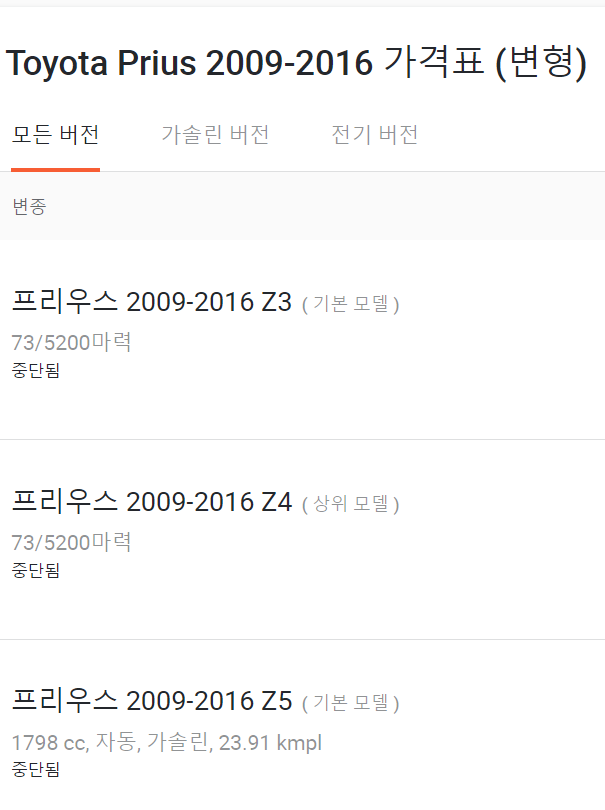

In [ ]:
#Toyota Prius 2009-2016 Z4(하이브리드)의 결측치 값을 23.91 kmpl로 변경
df_raw.loc[4446, 'Mileage'] = 23.91

In [ ]:
#Mahindra E Verito D4(전기차)의 결측치 삭제(결측치 1개라 모델에 영향 없을거라 판단)
df_raw = df_raw.dropna(subset=['Mileage'])

In [ ]:
#Engine, Power 결측치는 평균치 대체
df_raw['Engine'].fillna(df_raw['Engine'].mean(), inplace=True)
df_raw['Power'].fillna(df_raw['Power'].mean(), inplace=True)

Seats 결측치 브랜드별로 모아서 보려고 한 코드. 대부분의 자동차 좌석수는 5개이고 어떤브랜드는 좌석수가 다 결측치인 브랜드도 있어서 좌석수는 최빈값 대체

In [ ]:
# df_raw['Seats']에서 결측치를 포함하는 행과 , 이 중 'BMW'로 시작하는 것들만 뽑아서 출력
df_raw[df_raw['Seats'].isnull() | df_raw['Name'].str.startswith('BMW')]


,Name,Location,Price,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats
20,BMW 3 Series 320d,Kochi,28436.41,2014,32982,0,2,1,22.69,1995.0,190.0,5.0
86,BMW 5 Series 2003-2012 525d,Delhi,21308.14,2011,75000,0,2,2,16.73,1995.0,218.0,5.0
113,BMW 3 Series 320d Luxury Line,Mumbai,31808.92,2015,56087,0,2,1,22.69,1995.0,190.0,5.0
118,BMW 5 Series 2010-2013 525i,Mumbai,10730.72,2009,128000,1,2,1,10.80,2497.0,215.0,5.0
137,BMW 1 Series 118d Base,Coimbatore,26397.57,2015,31821,0,2,1,20.58,1995.0,143.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...
7176,BMW 3 Series Luxury Line,Coimbatore,95150.83,2017,22574,0,2,1,21.76,1995.0,190.0,5.0
7204,BMW 5 Series 2003-2012 520d,Delhi,NaN,2011,58067,0,2,1,18.48,1995.0,177.0,5.0
7209,BMW 5 Series 520d Luxury Line,Kochi,104042.00,2016,55615,0,2,1,22.48,1995.0,190.0,5.0
7216,BMW X5 xDrive 30d Design Pure Experience 5 Seater,Delhi,NaN,2015,31000,0,2,2,15.97,2993.0,258.0,5.0


마루티 브랜드의 데이터들을 모아봄. 이 브랜드의 데이터들은 다 Seats

In [ ]:
df_raw.loc[df_raw['Name'] == 'Maruti Swift 1.3 VXi']

,Name,Location,Price,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats
208,Maruti Swift 1.3 VXi,Kolkata,3234.55,2010,42001,1,1,1,16.1,1616.548293,112.770833,NaN
733,Maruti Swift 1.3 VXi,Chennai,2682.68,2006,97800,1,1,3,16.1,1616.548293,112.770833,NaN
2335,Maruti Swift 1.3 VXi,Mumbai,2682.68,2007,55000,1,1,2,16.1,1616.548293,112.770833,NaN
2668,Maruti Swift 1.3 VXi,Kolkata,6499.75,2014,32986,1,1,1,16.1,1616.548293,112.770833,NaN
3404,Maruti Swift 1.3 VXi,Jaipur,3602.46,2006,125000,1,1,4,16.1,1616.548293,112.770833,NaN
5015,Maruti Swift 1.3 VXi,Delhi,2452.74,2006,63000,1,1,1,16.1,1616.548293,112.770833,NaN
6651,Maruti Swift 1.3 VXi,Kolkata,NaN,2015,36009,1,1,1,16.1,1616.548293,112.770833,NaN
6685,Maruti Swift 1.3 VXi,Pune,NaN,2010,115000,1,1,2,16.1,1616.548293,112.770833,NaN


In [ ]:
#Seats 결측치는 최빈값 대체
mode_seats = df_raw['Seats'].mode()[0] #최빈값 중 첫 번째 값을 가져옴
df_raw['Seats'].fillna(mode_seats, inplace=True)

In [ ]:
df_raw.isnull().sum()

Name                    0
Location                0
Price                1053
Year                    0
Kilometers_Driven       0
Fuel_Type               0
Transmission            0
Owner_Type              0
Mileage                 0
Engine                  0
Power                   0
Seats                   0
dtype: int64

In [ ]:
df_raw[df_raw['Price'].isnull() == True]

,Name,Location,Price,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats
6019,Maruti Alto K10 LXI CNG,Delhi,NaN,2014,40929,2,1,1,32.26,998.0,58.200000,4.0
6020,Maruti Alto 800 2016-2019 LXI,Coimbatore,NaN,2013,54493,1,1,2,24.70,796.0,47.300000,5.0
6022,Toyota Etios Liva GD,Hyderabad,NaN,2012,139000,0,1,1,23.59,1364.0,112.770833,5.0
6023,Hyundai i20 Magna,Mumbai,NaN,2014,29000,1,1,1,18.50,1197.0,82.850000,5.0
6024,Mahindra XUV500 W8 2WD,Coimbatore,NaN,2016,85609,0,1,2,16.00,2179.0,140.000000,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...
7248,Volkswagen Vento Diesel Trendline,Hyderabad,NaN,2011,89411,0,1,1,20.54,1598.0,103.600000,5.0
7249,Volkswagen Polo GT TSI,Mumbai,NaN,2015,59000,1,2,1,17.21,1197.0,103.600000,5.0
7250,Nissan Micra Diesel XV,Kolkata,NaN,2012,28000,0,1,1,23.08,1461.0,63.100000,5.0
7251,Volkswagen Polo GT TSI,Pune,NaN,2013,52262,1,2,3,17.20,1197.0,103.600000,5.0


여러분 목표변수 결측치 대체 어떤 방법 할까요? 1053개  

1. 삭제(전기수 사람이 했던 방법)
2. 결측값이 있는 데이터를 예측값으로 두고 회귀분석하기 (교재에 있는 방법, 다만 힘들 것으로 예상)  
3. 기준을 정하고 기준값 대체

### 이상치 처리

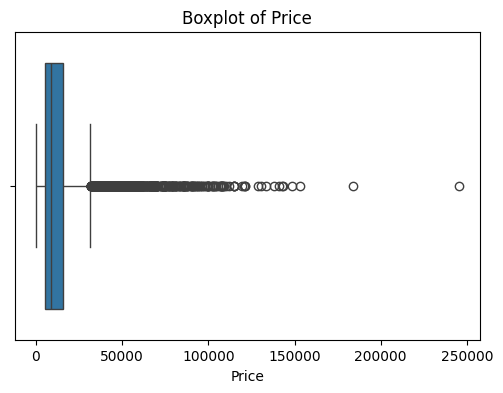

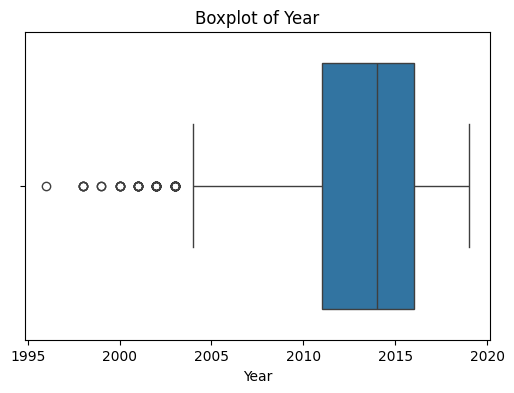

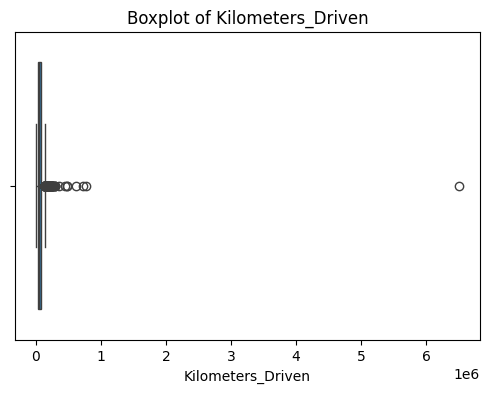

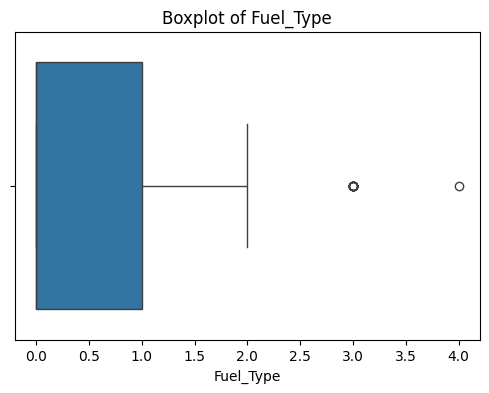

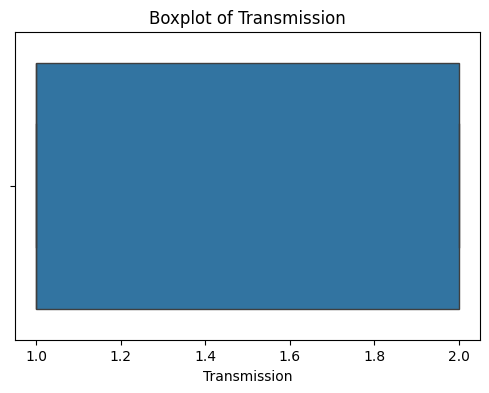

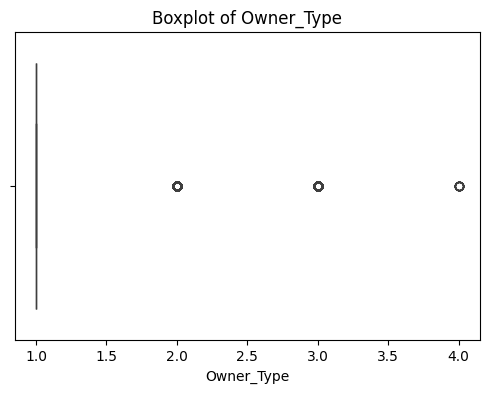

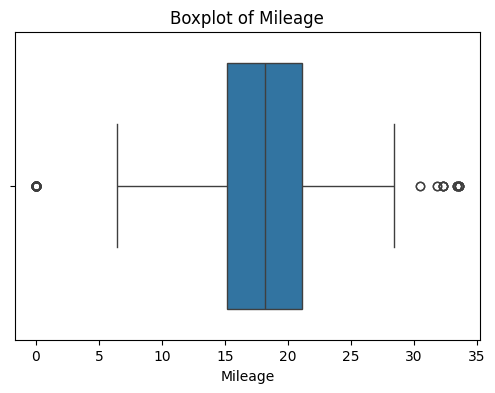

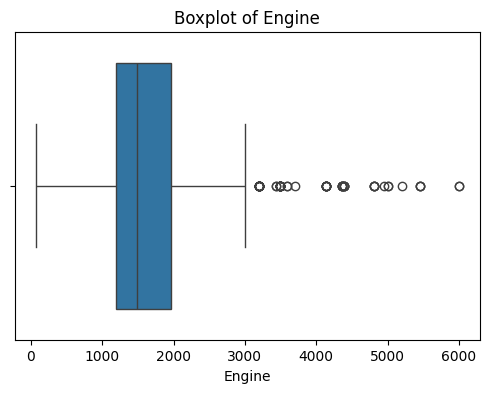

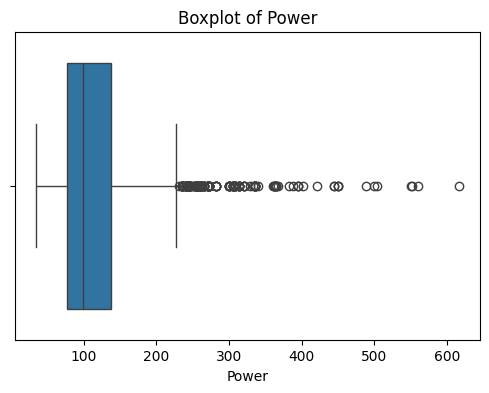

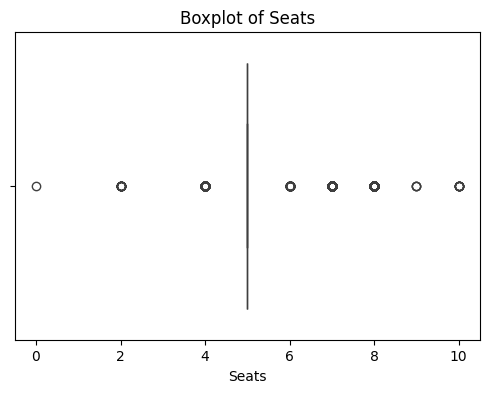

In [ ]:

numeric_cols = df_raw.select_dtypes(include=['int', 'float']).columns

# 각 숫자형 변수에 대한 Boxplot 그리기
for column in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df_raw[column])
    plt.title(f'Boxplot of {column}')
    plt.xlabel(column)
    plt.show()


seats(좌석수)가 0은 이상치로 간주  
mileage 0 은 이상치 간주  
kilometers_driven 터무니없는 높은 값은 이상치 간

In [ ]:
df_raw[df_raw['Seats'] == 0]

,Name,Location,Price,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats
3999,Audi A4 3.2 FSI Tiptronic Quattro,Hyderabad,27593.28,2012,125000,1,2,1,10.5,3197.0,112.770833,0.0


In [ ]:
#Seats 이상치 1개는 삭제
df_raw = df_raw[df_raw['Seats'] != 0] #Seats수가 0개인 차 삭제(이상치로 판별)

In [ ]:
df_raw[df_raw['Mileage'] == 0]

,Name,Location,Price,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats
14,Land Rover Freelander 2 TD4 SE,Pune,26826.80,2012,85000,0,2,2,0.0,2179.000000,115.000000,5.0
67,Mercedes-Benz C-Class Progressive C 220d,Coimbatore,54680.68,2019,15369,0,2,1,0.0,1950.000000,194.000000,5.0
79,Hyundai Santro Xing XL,Hyderabad,1992.85,2005,87591,1,1,1,0.0,1086.000000,112.770833,5.0
194,Honda City 1.5 GXI,Ahmedabad,4522.23,2007,60006,1,1,1,0.0,1616.548293,112.770833,5.0
229,Ford Figo Diesel,Bangalore,5518.66,2015,70436,0,1,1,0.0,1498.000000,99.000000,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...
6633,Mahindra TUV 300 P4,Kolkata,NaN,2016,27000,0,1,1,0.0,1616.548293,112.770833,5.0
6697,Hyundai Santro Xing XL,Jaipur,NaN,2007,85000,1,1,2,0.0,1086.000000,112.770833,5.0
6857,Land Rover Freelander 2 TD4 SE,Mumbai,NaN,2011,87000,0,2,1,0.0,2179.000000,115.000000,5.0
6957,Honda Jazz 2020 Petrol,Kochi,NaN,2019,11574,1,1,1,0.0,1199.000000,88.700000,5.0


In [ ]:
#Mileage 에서 0이 아닌값들의 평균 계산
Mileage_mean = df_raw[df_raw['Mileage'] != 0]['Mileage'].mean()
#이상치(0) 평균값 대체
df_raw['Mileage'].replace(0.0, Mileage_mean, inplace=True)

In [ ]:
#kilometers_driven에서 터무니없는 큰 값이 관측됨.

Q1 = df_raw['Kilometers_Driven'].quantile(0.25)
Q3 = df_raw['Kilometers_Driven'].quantile(0.75)
IQR = Q3 - Q1

# IQR 규칙을 사용하여 이상치를 필터링
df_raw = df_raw[~((df_raw['Kilometers_Driven'] < (Q1 - 1.5 * IQR)) | (df_raw['Kilometers_Driven'] > (Q3 + 1.5 * IQR)))]

<Axes: ylabel='Kilometers_Driven'>

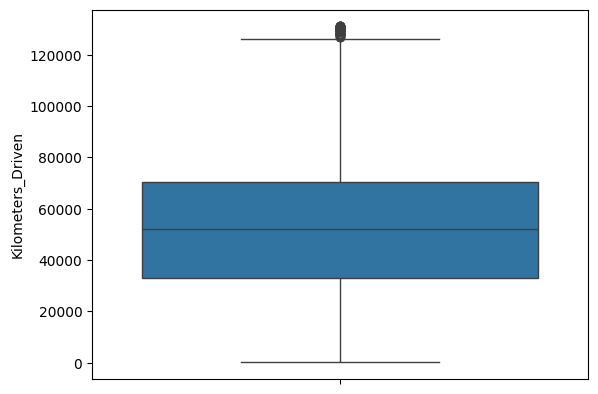

In [ ]:
sns.boxplot(df_raw['Kilometers_Driven']) #이상치 필터링 후 다시 boxplot 확인

In [ ]:
df_raw.describe() #기술통계량 재확인

,Price,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats
count,5995.000000,6993.000000,6993.000000,6993.000000,6993.000000,6993.000000,6993.000000,6993.000000,6993.000000,6993.000000
mean,15103.574485,2013.479336,53494.027599,0.491777,1.288717,1.192478,18.421311,1605.457761,112.918400,5.253539
std,17864.228193,3.188071,26979.944031,0.528882,0.453199,0.445375,4.115407,589.039227,53.283965,0.773513
min,7.080000,1996.000000,171.000000,0.000000,1.000000,1.000000,6.400000,72.000000,34.200000,2.000000
25%,5442.010000,2012.000000,33000.000000,0.000000,1.000000,1.000000,15.600000,1197.000000,78.000000,5.000000
50%,8814.520000,2014.000000,52000.000000,0.000000,1.000000,1.000000,18.348397,1493.000000,98.600000,5.000000
75%,16096.080000,2016.000000,70521.000000,1.000000,2.000000,1.000000,21.100000,1968.000000,138.030000,5.000000
max,245273.600000,2019.000000,131000.000000,4.000000,2.000000,4.000000,33.540000,5998.000000,616.000000,10.000000


Mileage, Seats값이 0인 이상치들이 제거되었고 Kilometers_Driven	최댓값 또한 131000로 변경됨

Engine 최솟값이 72로 나와있는데, 보통 차의 engine은 1000cc 이상이라고 한다. 이상치로 간주하고 삭제!

In [ ]:
df_raw[df_raw['Engine'] == 72.0]

,Name,Location,Price,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats
4446,Mahindra E Verito D4,Chennai,19928.48,2016,50000,4,2,1,23.91,72.0,41.0,5.0


In [ ]:
df_raw = df_raw[df_raw['Engine'] != 72.0]


In [ ]:
df_raw

,Name,Location,Price,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats
0,Maruti Wagon R LXI CNG,Mumbai,2682.68,2010,72000,2,1,1,26.60,998.0,58.16,5.0
1,Hyundai Creta 1.6 CRDi SX Option,Pune,19162.00,2015,41000,0,1,1,19.67,1582.0,126.20,5.0
2,Honda Jazz V,Chennai,6898.32,2011,46000,1,1,1,18.20,1199.0,88.70,5.0
3,Maruti Ertiga VDI,Chennai,9197.76,2012,87000,0,1,1,20.77,1248.0,88.76,7.0
4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,27194.71,2013,40670,0,2,2,15.20,1968.0,140.80,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...
7248,Volkswagen Vento Diesel Trendline,Hyderabad,NaN,2011,89411,0,1,1,20.54,1598.0,103.60,5.0
7249,Volkswagen Polo GT TSI,Mumbai,NaN,2015,59000,1,2,1,17.21,1197.0,103.60,5.0
7250,Nissan Micra Diesel XV,Kolkata,NaN,2012,28000,0,1,1,23.08,1461.0,63.10,5.0
7251,Volkswagen Polo GT TSI,Pune,NaN,2013,52262,1,2,3,17.20,1197.0,103.60,5.0


In [ ]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 6992 entries, 0 to 7252
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               6992 non-null   object 
 1   Location           6992 non-null   object 
 2   Price              5994 non-null   float64
 3   Year               6992 non-null   int64  
 4   Kilometers_Driven  6992 non-null   int64  
 5   Fuel_Type          6992 non-null   int64  
 6   Transmission       6992 non-null   int64  
 7   Owner_Type         6992 non-null   int64  
 8   Mileage            6992 non-null   float64
 9   Engine             6992 non-null   float64
 10  Power              6992 non-null   float64
 11  Seats              6992 non-null   float64
dtypes: float64(5), int64(5), object(2)
memory usage: 710.1+ KB


In [ ]:
df_noprice = df_raw.dropna(subset=['Price'])

In [ ]:
#여기까지 데이터프레임 csv파일로 저장 , Price결측치 뺀 데이터프레임

df_noprice.to_csv('noprice.csv', index=False)

### 파생변수 추가

1. Brand

In [ ]:
#자동차 모델 종류 개수 확인
len(np.unique(list(df_raw.Name)))

1993

In [ ]:
df_raw['Brand'] = df_raw.Name.apply(lambda x:x.split()[0])

In [ ]:
#파생변수 생성으로 name 변수 제거
df_raw = df_raw.drop(['Name'], axis = 1)

2. Vehicle_Age

In [ ]:
#차량 연식 추가 (현재년도-차량모델년도)

import datetime
current_year = datetime.datetime.now().year
df_raw['Vehicle_Age'] = current_year - df_raw['Year']

In [ ]:
# Year 변수는 필요없어졌기에 제거
df_raw = df_raw.drop(['Year'], axis = 1)

3. Brands 자동차 등급 분류

이 부분에도 전기수는 브랜드 30갠데 우리는 32개 이유는 목표변수 결측치 1000개 삭제하니 브랜드도 없어진듯 그래서 ford 추가해서

In [ ]:
brand_count = df_raw['Brand'].nunique()
print('차 브랜드 개수 : {}'.format(brand_count))

unique_brands = df_raw['Brand'].unique()
print(unique_brands)

차 브랜드 개수 : 32
['Maruti' 'Hyundai' 'Honda' 'Audi' 'Nissan' 'Toyota' 'Volkswagen' 'Tata'
 'Land' 'Mitsubishi' 'Renault' 'Mercedes-Benz' 'BMW' 'Mahindra' 'Ford'
 'Porsche' 'Datsun' 'Jaguar' 'Volvo' 'Chevrolet' 'Skoda' 'Mini' 'Fiat'
 'Jeep' 'Smart' 'Ambassador' 'ISUZU' 'Force' 'Bentley' 'Lamborghini'
 'Hindustan' 'OpelCorsa']


In [ ]:
brand_groups = { #브랜드 등급별로 분류
    'GeneralBrands': ['Maruti', 'Hyundai', 'Honda', 'Toyota', 'Nissan', 'Tata', 'Mitsubishi', 'Renault', 'Mahindra',
                       'Chevrolet', 'Skoda', 'Fiat', 'Jeep', 'Ambassador', 'ISUZU', 'Force', 'Hindustan','Ford'], #일반 브랜드
    'PremiumBrands': ['Audi', 'Volkswagen', 'Porsche', 'Mercedes-Benz', 'BMW', 'Jaguar', 'Volvo', 'Land', 'Bentley', 'Lamborghini'], #프리미엄 브랜드
    'CompactBrands': ['Datsun', 'Mini', 'Smart', 'OpelCorsa'] #소형 브랜드
}

df_raw['Brand_Group'] = df_raw['Brand'].map({brand: group for group, brands in brand_groups.items() for brand in brands})

In [ ]:
# General -> 1, Premium -> 2, Compact -> 3
df_raw['Brand_Group'] = df_raw['Brand_Group'].replace('GeneralBrands', 1)
df_raw['Brand_Group'] = df_raw['Brand_Group'].replace('PremiumBrands', 2)
df_raw['Brand_Group'] = df_raw['Brand_Group'].replace('CompactBrands', 3)

In [ ]:
from sklearn.preprocessing import LabelEncoder #Brand 데이터 값 수치형으로 변환

le = LabelEncoder()
df_raw['Brand'] = le.fit_transform(df_raw['Brand'])

brand_mapping = dict(zip(le.classes_, range(len(le.classes_))))
print(brand_mapping)

{'Ambassador': 0, 'Audi': 1, 'BMW': 2, 'Bentley': 3, 'Chevrolet': 4, 'Datsun': 5, 'Fiat': 6, 'Force': 7, 'Ford': 8, 'Hindustan': 9, 'Honda': 10, 'Hyundai': 11, 'ISUZU': 12, 'Jaguar': 13, 'Jeep': 14, 'Lamborghini': 15, 'Land': 16, 'Mahindra': 17, 'Maruti': 18, 'Mercedes-Benz': 19, 'Mini': 20, 'Mitsubishi': 21, 'Nissan': 22, 'OpelCorsa': 23, 'Porsche': 24, 'Renault': 25, 'Skoda': 26, 'Smart': 27, 'Tata': 28, 'Toyota': 29, 'Volkswagen': 30, 'Volvo': 31}


4. location

In [ ]:
df_raw.Location.unique()

array(['Mumbai', 'Pune', 'Chennai', 'Coimbatore', 'Hyderabad', 'Jaipur',
       'Kochi', 'Kolkata', 'Delhi', 'Bangalore', 'Ahmedabad'],
      dtype=object)

In [ ]:
#지역을 동서남북으로 나누어 city_location 파생변수 생성
east = ['Kolkata']
west = ['Mumbai', 'Pune', 'Ahmedabad']
south = ['Chennai', 'Coimbatore', 'Kochi', 'Hyderabad', 'Bangalore']
north = ['Jaipur', 'Delhi']

def city2ewsn(city):
    if city in east:
        return 'east'
    elif city in west:
        return 'west'
    elif city in south:
        return 'south'
    elif city in north:
        return 'north'

df_raw['city_location'] = df_raw.Location.apply(city2ewsn)

In [ ]:
# Location 변수는 필요없어졌기에 제거
df_raw = df_raw.drop(['Location'], axis = 1)

In [ ]:
# 동부 -> 1, 서부 -> 2, 남부 -> 3, 북부 -> 4
df_raw['city_location'] = df_raw['city_location'].replace('east', 1)
df_raw['city_location'] = df_raw['city_location'].replace('west', 2)
df_raw['city_location'] = df_raw['city_location'].replace('south', 3)
df_raw['city_location'] = df_raw['city_location'].replace('north', 4)

In [ ]:
df_raw.isnull().sum()

Price                998
Kilometers_Driven      0
Fuel_Type              0
Transmission           0
Owner_Type             0
Mileage                0
Engine                 0
Power                  0
Seats                  0
Brand                  0
Vehicle_Age            0
Brand_Group            0
city_location          0
dtype: int64

In [ ]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 6992 entries, 0 to 7252
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Price              5994 non-null   float64
 1   Kilometers_Driven  6992 non-null   int64  
 2   Fuel_Type          6992 non-null   int64  
 3   Transmission       6992 non-null   int64  
 4   Owner_Type         6992 non-null   int64  
 5   Mileage            6992 non-null   float64
 6   Engine             6992 non-null   float64
 7   Power              6992 non-null   float64
 8   Seats              6992 non-null   float64
 9   Brand              6992 non-null   int64  
 10  Vehicle_Age        6992 non-null   int64  
 11  Brand_Group        6992 non-null   int64  
 12  city_location      6992 non-null   int64  
dtypes: float64(5), int64(8)
memory usage: 764.8 KB


In [ ]:
df_raw

,Price,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Brand,Vehicle_Age,Brand_Group,city_location
0,2682.68,72000,2,1,1,26.60,998.0,58.16,5.0,18,14,1,2
1,19162.00,41000,0,1,1,19.67,1582.0,126.20,5.0,11,9,1,2
2,6898.32,46000,1,1,1,18.20,1199.0,88.70,5.0,10,13,1,3
3,9197.76,87000,0,1,1,20.77,1248.0,88.76,7.0,18,12,1,3
4,27194.71,40670,0,2,2,15.20,1968.0,140.80,5.0,1,11,2,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7248,NaN,89411,0,1,1,20.54,1598.0,103.60,5.0,30,13,2,3
7249,NaN,59000,1,2,1,17.21,1197.0,103.60,5.0,30,9,2,2
7250,NaN,28000,0,1,1,23.08,1461.0,63.10,5.0,22,12,1,1
7251,NaN,52262,1,2,3,17.20,1197.0,103.60,5.0,30,11,2,2


In [ ]:
#Price 결측치 남긴 데이터프레임 저장

df_raw.to_csv('df_car.csv', index=False)

In [ ]:
df_raw

,Price,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Brand,Vehicle_Age,Brand_Group,city_location
0,2682.68,72000,2,1,1,26.60,998.0,58.16,5.0,18,14,1,2
1,19162.00,41000,0,1,1,19.67,1582.0,126.20,5.0,11,9,1,2
2,6898.32,46000,1,1,1,18.20,1199.0,88.70,5.0,10,13,1,3
3,9197.76,87000,0,1,1,20.77,1248.0,88.76,7.0,18,12,1,3
4,27194.71,40670,0,2,2,15.20,1968.0,140.80,5.0,1,11,2,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7248,NaN,89411,0,1,1,20.54,1598.0,103.60,5.0,30,13,2,3
7249,NaN,59000,1,2,1,17.21,1197.0,103.60,5.0,30,9,2,2
7250,NaN,28000,0,1,1,23.08,1461.0,63.10,5.0,22,12,1,1
7251,NaN,52262,1,2,3,17.20,1197.0,103.60,5.0,30,11,2,2


In [ ]:
df_final = df_raw.dropna(subset=['Price'])

In [ ]:
df_final

,Price,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Brand,Vehicle_Age,Brand_Group,city_location
0,2682.68,72000,2,1,1,26.60,998.0,58.16,5.0,18,14,1,2
1,19162.00,41000,0,1,1,19.67,1582.0,126.20,5.0,11,9,1,2
2,6898.32,46000,1,1,1,18.20,1199.0,88.70,5.0,10,13,1,3
3,9197.76,87000,0,1,1,20.77,1248.0,88.76,7.0,18,12,1,3
4,27194.71,40670,0,2,2,15.20,1968.0,140.80,5.0,1,11,2,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7228,10822.70,41413,0,1,1,27.28,1047.0,69.00,5.0,28,8,1,2
7231,13474.72,39015,1,1,1,17.00,1497.0,121.36,5.0,8,7,1,3
7232,27838.55,6000,1,1,1,16.00,1368.0,160.00,5.0,14,6,1,2
7235,16203.39,21380,0,1,1,24.30,1248.0,88.50,5.0,18,7,1,3


Price 결측치 삭제하고 파생변수 저장된 최종 코드 저장

In [ ]:
df_final.to_csv('car_final.csv', index=False)